<a href="https://colab.research.google.com/github/Pavlenko-Kateryna/da_course/blob/main/HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/course_da/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [11]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

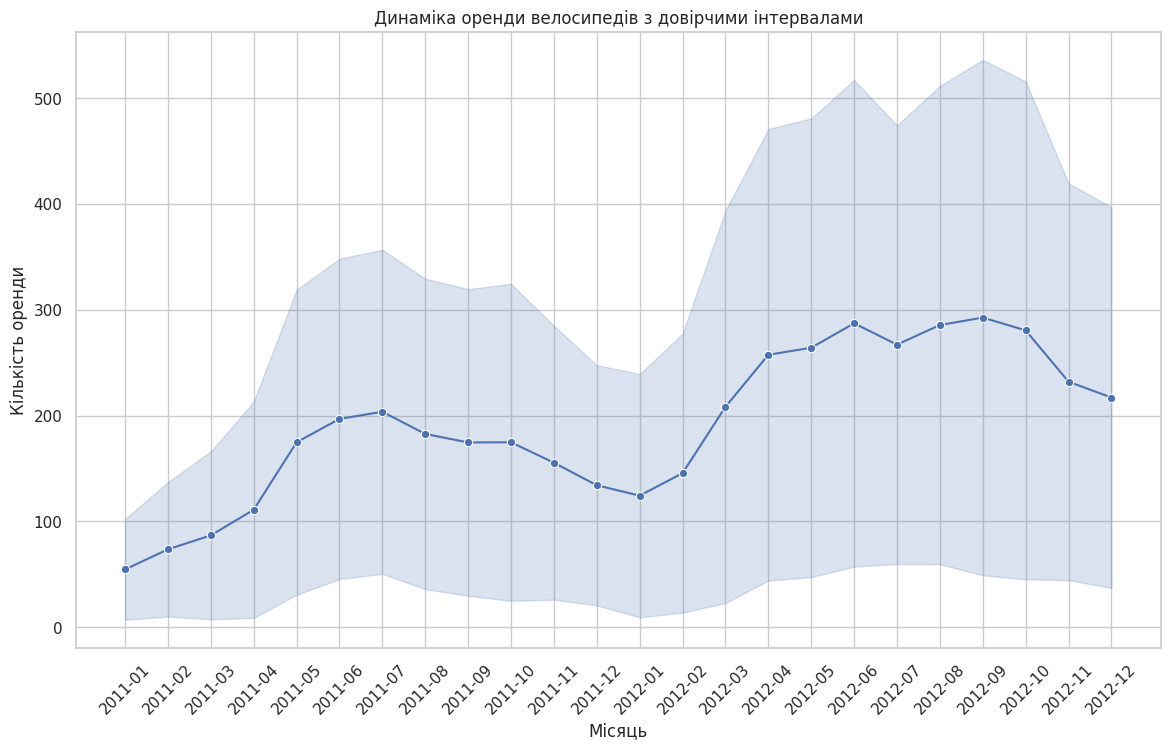

In [15]:
plt.figure(figsize=(14,8))
sns.lineplot(df, x = df['month_year'], y = df['count'], errorbar='sd', marker = 'o')
plt.title("Динаміка оренди велосипедів з довірчими інтервалами")
plt.xlabel("Місяць")
plt.ylabel("Кількість оренди")
plt.xticks(rotation=45)
plt.show()

Найбільша невизначеність (широкий довірчий інтервал) спостерігається у період з липня по грудень 2011 року

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

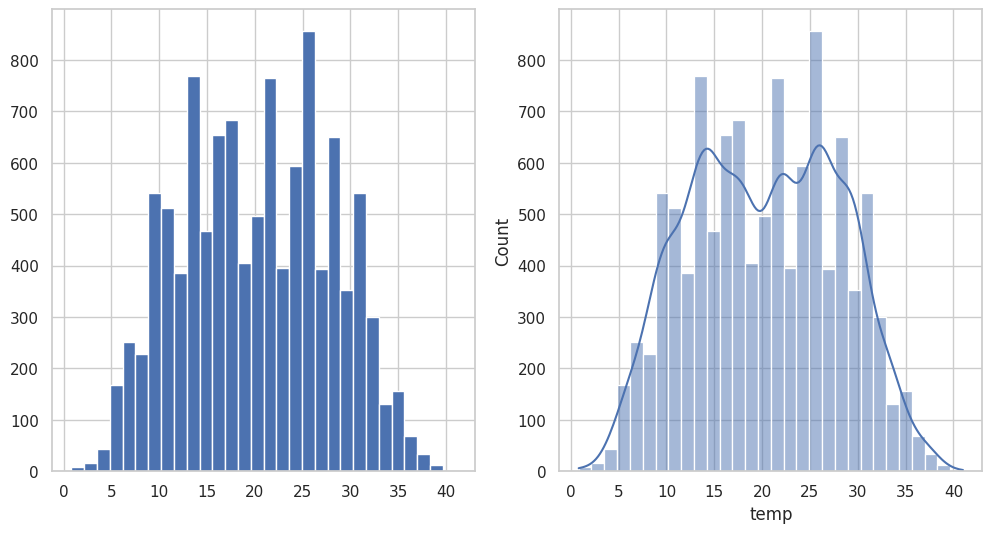

In [28]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].hist(df['temp'], bins = 30)
ax[1] = sns.histplot(data = df, x = df['temp'], bins = 30, kde=True)
plt.show()

1. Графіки відрізняються візуалізацією, seaborn показує більш пастельні кольори, які мають більшу прозорість. А pandas показує стандартний колір, без прозорості. У seaborn одразу підписуються осі, у pandas це необхідно робити вручну
2. Можливо це лінійний графік розподілу, який показує розподіл температури. (загуглила і виявилось, що це крива щільності розподілу, яка показує тенденцію розподілу)

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

/tmp/ipykernel_4940/2908462140.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Ясно", "Туман", "Легкий дощ", "Сильний дощ"])


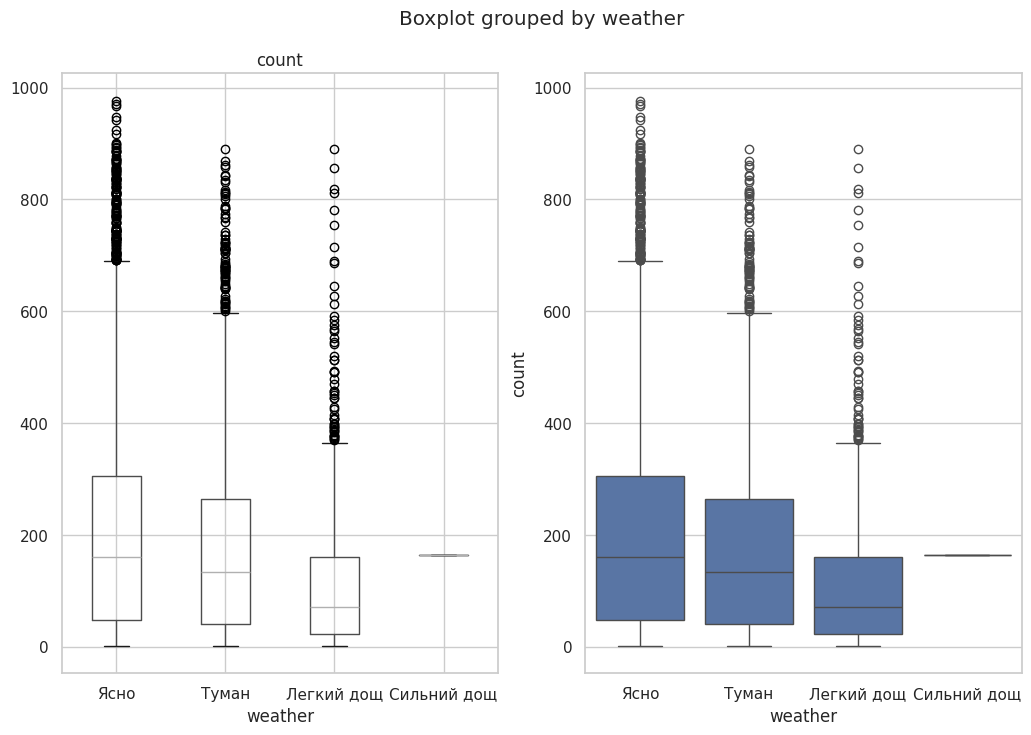

In [46]:
fig, ax = plt.subplots(1,2, figsize = (12,8))
df.boxplot(
    column = 'count',
    by = 'weather',
    ax = ax[0]

)
ax[0].set_xticklabels(["Ясно", "Туман", "Легкий дощ", "Сильний дощ"])
ax[1] = sns.boxplot(
    data = df,
    x = df['weather'],
    y = df['count']
)
ax[1].set_xticklabels(["Ясно", "Туман", "Легкий дощ", "Сильний дощ"])
plt.show()

У seaborn ще додаєтьсяк колір до boxes і вони більш широкі, і на графіку наведені тільки горизонтальна сітка, на відміну від pandas, де наявна вся сітка і вужчі boxes та відсутність кольору

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


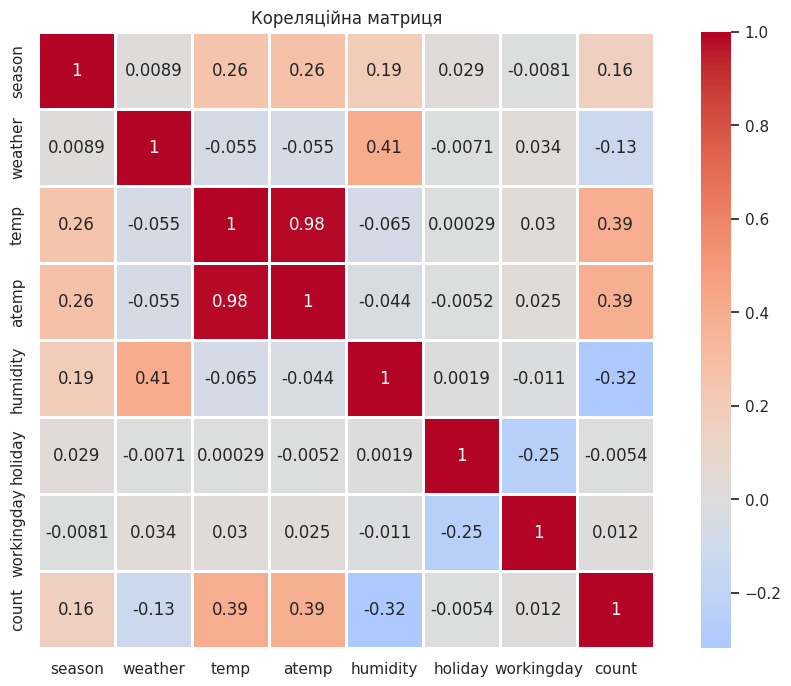

In [51]:
correlation = df[['season', 'weather', 'temp', 'atemp', 'humidity','holiday', 'workingday', 'count']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title("Кореляційна матриця")
plt.show()

1. Найбільше з count корелює температура (та відчуття температури)
2. Кореляція між temp та atemp буде висока, тому що є мінімальна різниця між температурою та тим, як вона відчувається
3. Негативна кореляція є між температурою та погодою, температурою та кількістю замовлень, вологістю і температурою, святковим днем і погодою, відчуттям температури, робочим днем, кількістю замовлень та вологістю

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


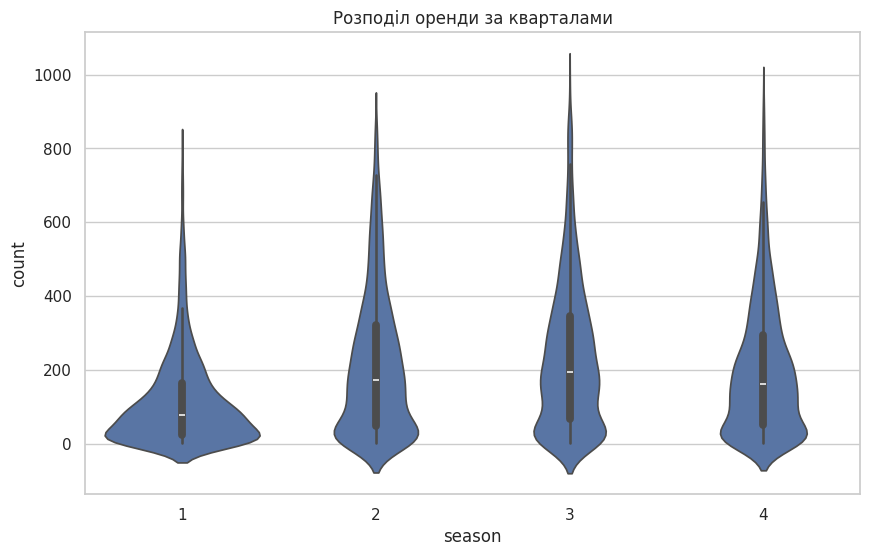

In [56]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x = 'season', y = 'count')
plt.title("Розподіл оренди за кварталами")
plt.show()

In [58]:
df.groupby('season')['count'].std()

,count
season,
1,125.273974
2,192.007843
3,197.151001
4,177.622409


1. Показує щільність розподілу даних, тобто їх найбільше зосередження даних у певному діапазоні
2. Можливо, більшу варіантивність має 3 квартиль, адже тут форма довга і трохи випукла, ще може бути 2 квартиль, адже він за розпоідом схожий на 3 (можемо перевірити за допомогою стандартного відхилення (чим більше std, тим більша варіантивність) (підтвердимо розрахунком вище)
3. Violin plot показує форму розподілу значень, можливість побачити піки (випуклість), у той час як boxplot цього не враховує

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

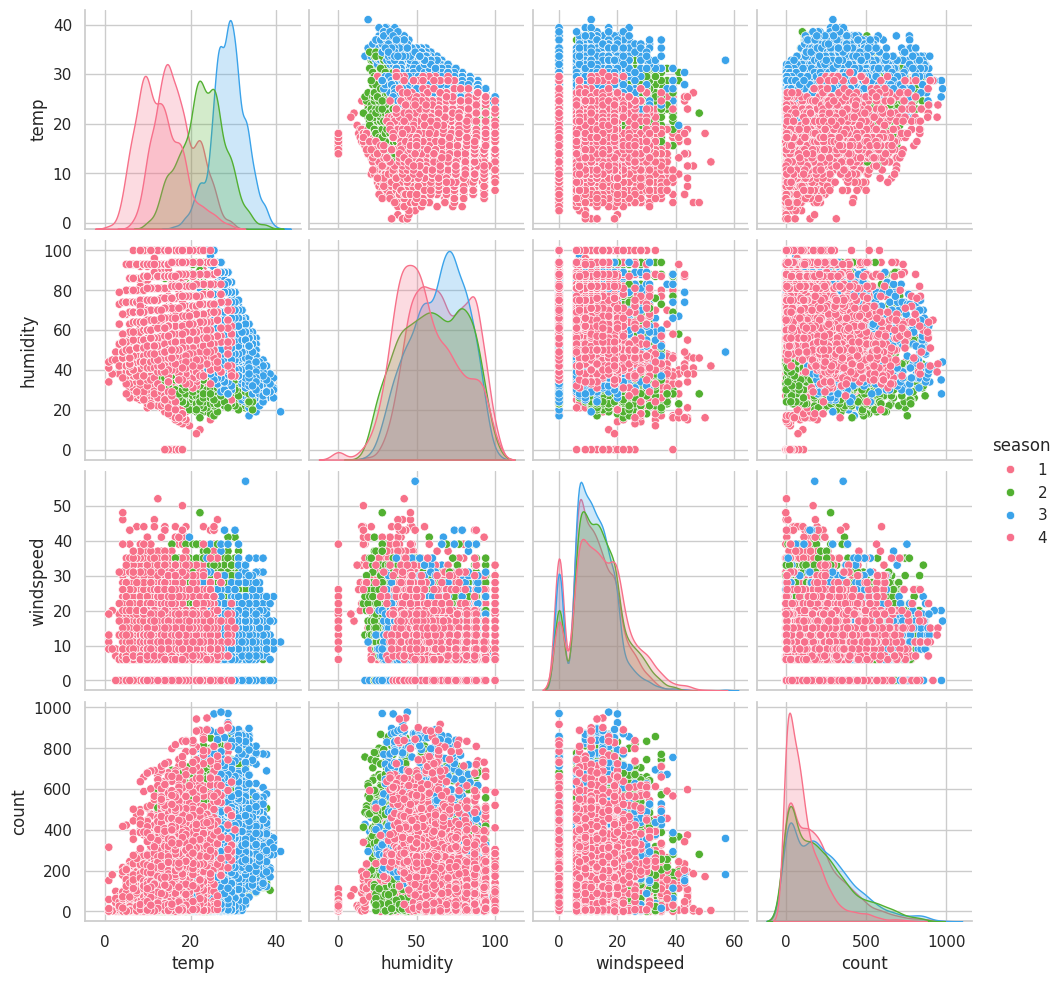

In [65]:
data = df[['temp', 'humidity', 'windspeed', 'count', 'season']]
sns.pairplot(data, hue='season', palette='husl')
plt.show()

1. Між змінними температури та кількістю замовлень спостерігається найбільший зв'язок, адже точки утворюють нахил вгору
2. Найбільше відрізняєтсья температура, адже гістограми більш у різних місяцях

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

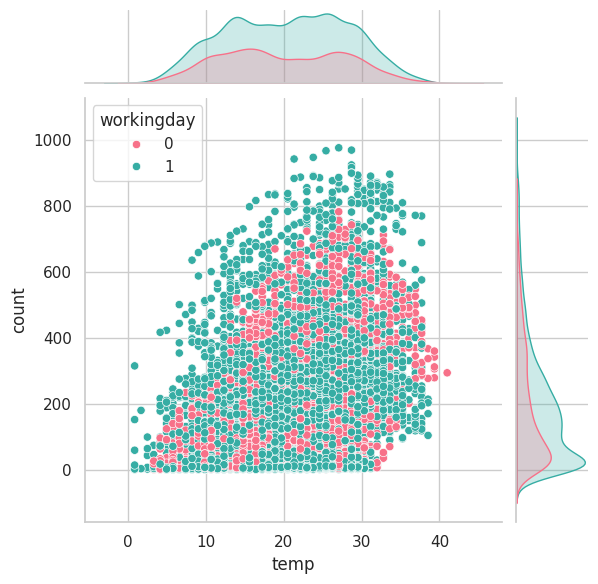

In [68]:
sns.jointplot(data=df, x = 'temp', y = 'count', hue='workingday', palette='husl')
plt.show()

1. Графіки по краях показують розподіли, а саме: зверху розподіл температури за робочими/неробочими днями, справа - розподіл оренд у робочі/неробочі дні. Посеред розподіл оренд від температури
2. Так, є різниця. Люди більше користуються орендою в робочий час? Розподіли графіків температури схожі